In [6]:
import numpy as np 
import pandas as pd 
import data_clean_utils

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, PowerTransformer, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator

from sklearn.model_selection import train_test_split, cross_val_score

In [7]:
!pip install mlflow dagshub

In [8]:
import dagshub
dagshub.init(
    repo_owner='anni0955',
    repo_name='delivery-time-prediction',
    mlflow=True
)

Initialized MLflow to track repo "anni0955/delivery-time-prediction"

Repository anni0955/delivery-time-prediction initialized!

In [10]:
import mlflow
mlflow.set_experiment('Exp3 - Model Selection(corrected)')

2026/03/17 13:13:36 INFO mlflow.tracking.fluent: Experiment with name 'Exp3 - Model Selection(corrected)' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/a6c6340ab0754f328fa47c93801f8aa4', creation_time=1773753216897, experiment_id='4', last_update_time=1773753216897, lifecycle_stage='active', name='Exp3 - Model Selection(corrected)', tags={}, workspace='default'>

In [11]:
from sklearn import set_config
set_config(transform_output='pandas')

In [12]:
df = pd.read_csv('train.csv')

In [13]:
data_clean_utils.perform_data_cleanining(df)

In [14]:
df = pd.read_csv('cleaned-data.csv')
df

,rider_id,rider_age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846,short
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,CHEN,11,3,friday,0,15.0,23.0,night,4.657195,short
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393,medium


In [15]:
cols_to_drop = [
    'rider_id',
    'restaurant_latitude',
    'restaurant_longitude', 
    'delivery_latitude', 
    'delivery_longitude',
    'order_date',
    'order_time_hour',
    'order_day',
    'city_name',
    'order_day_of_week',
    'order_month'
]

df.drop(columns=cols_to_drop, inplace=True)
df

,rider_age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24,1,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,1,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,30.0,4.8,windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,0,10.0,morning,1.489846,short
45498,21.0,4.6,windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,36,0,15.0,evening,NaN,NaN
45499,30.0,4.9,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,0,15.0,night,4.657195,short
45500,20.0,4.7,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,0,5.0,afternoon,6.232393,medium


In [16]:
df.isna().sum()

,0
rider_age,1854
ratings,1908
weather,525
traffic,510
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,993
festival,228
city_type,1198


<Axes: >

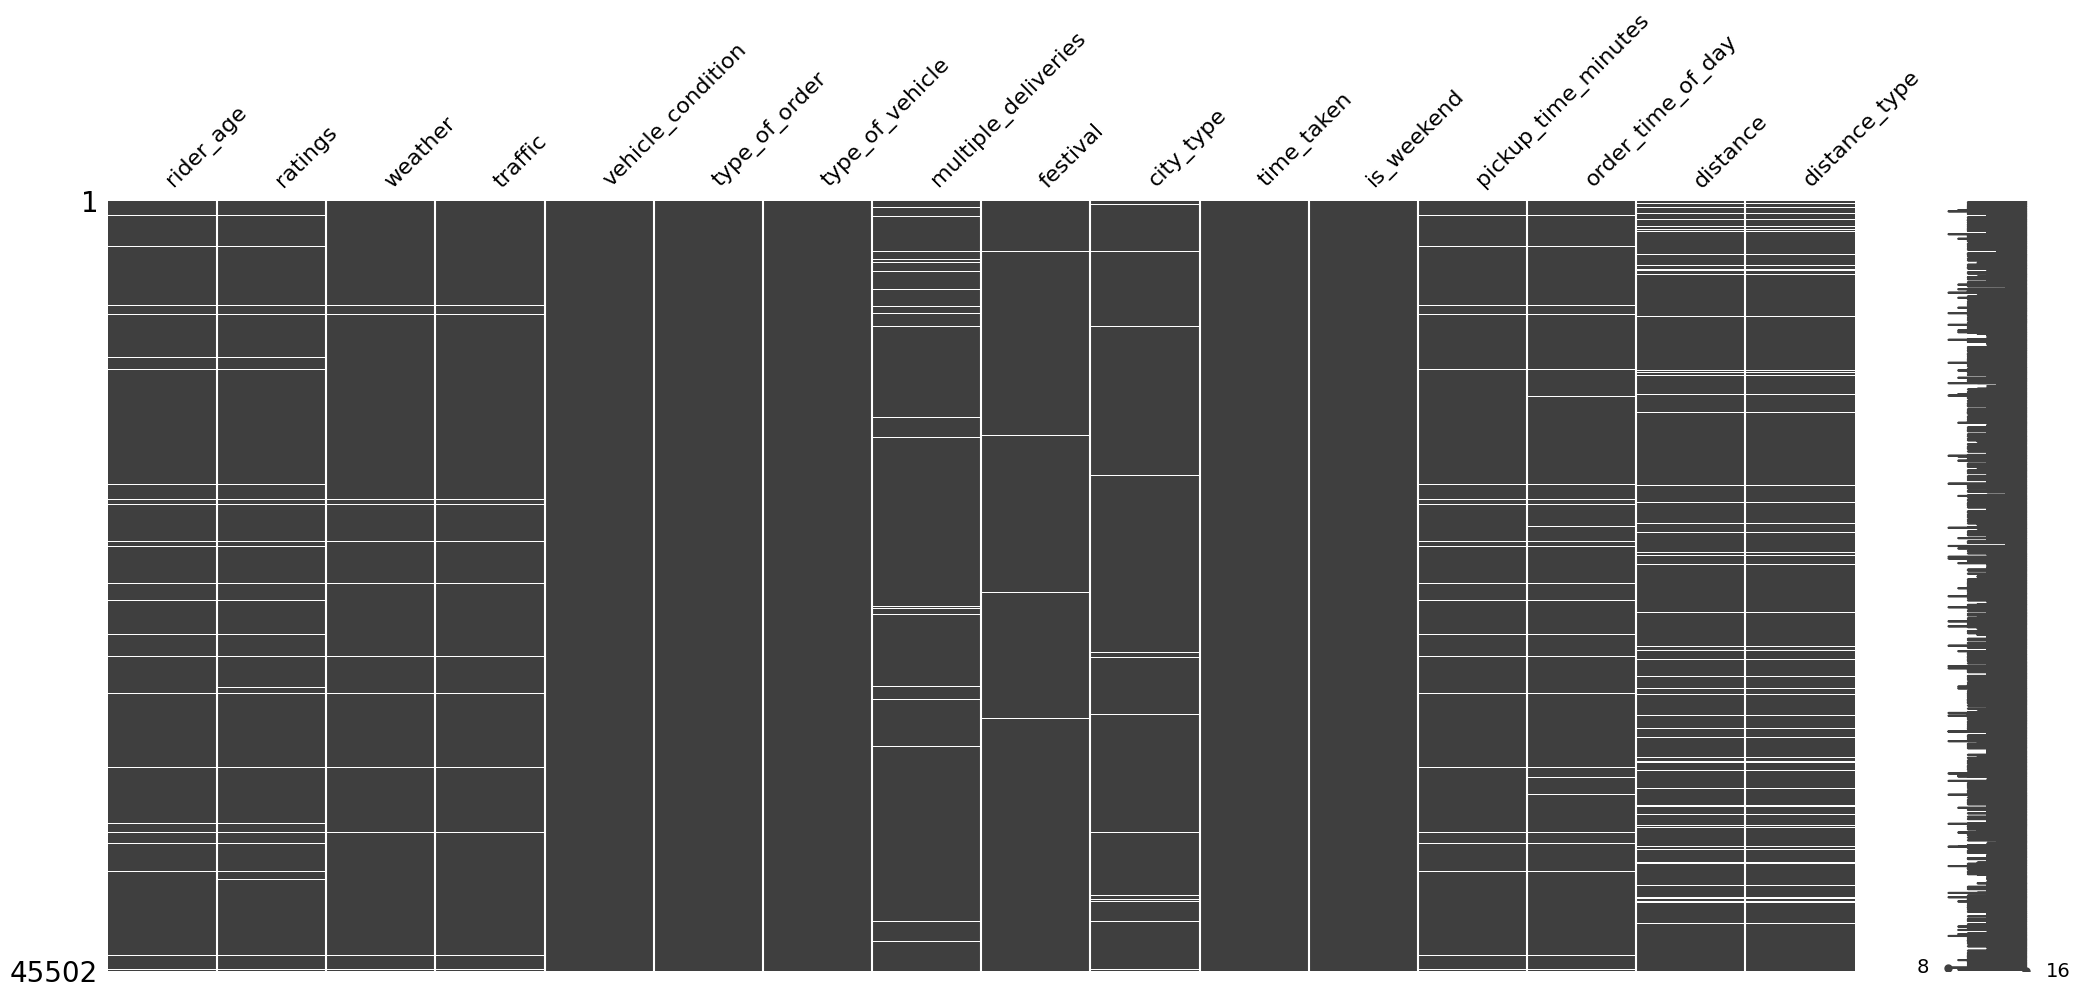

In [17]:
import missingno as msno
msno.matrix(df)

In [18]:
missing_col =  (
    df
    .isna()
    .any(axis=0)
    .loc[lambda x: x]
    .index
)

missing_col

Index(['rider_age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [19]:
temp_df = df.copy().dropna()

In [20]:
x = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)

x_train.isna().sum()

,0
rider_age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,0
festival,0
city_type,0


In [22]:
pt = PowerTransformer()
y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [23]:
(
    x_train
    .isna()
    .any(axis=1)
    .mean()
    .round(2)*100
)

np.float64(0.0)

## preprocessing pipeline

In [24]:
num_cols = ['rider_age', 'ratings', 
            'pickup_time_minutes', 'distance']

nominal_cat_cols = ['weather', 'type_of_vehicle', 'festival',
                    'city_type',
                    'is_weekend',
                    'order_time_of_day', 'type_of_order']

ordinal_cat_cols = ['traffic', 'distance_type']

In [25]:
traffic_order = ['low', 'medium', 'high', 'jam']
distance_type_order = ['short', 'medium', 'long', 'very_long'] 

In [26]:
preprocessor = ColumnTransformer(transformers=[
    ('scale', MinMaxScaler(), num_cols),
    ('nominal_encode', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), nominal_cat_cols),
    ('ordinal_encode', OrdinalEncoder(categories=[traffic_order, distance_type_order], encoded_missing_value=-999, handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cat_cols),
], remainder='passthrough', n_jobs=-1, verbose_feature_names_out=False, force_int_remainder_cols=False)

preprocessor

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['rider_age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_vehicle', 'festival',
                                  'city_type', 'is_weekend',
                                  'order_time_of_day', 'type_of_order']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']],
                                                encoded_missing_value=-999,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [27]:
preprocessing_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

preprocessing_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                                   remainder='passthrough',
                                   transformers=[('scale', MinMaxScaler(),
                                                  ['rider_age', 'ratings',
                                                   'pickup_time_minutes',
                                                   'distance']),
                                                 ('nominal_encode',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['weather', 'type_of_vehicle',
                                                   'festival', 'city_type',
                                                   'is_weekend',
                                                   'order_time_of_day',
                                                   'type_of_order']),
                                                 ('ordinal_encode',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam'],
                                                                             ['short',
                                                                              'medium',
                                                                              'long',
                                                                              'very_long']],
                                                                 encoded_missing_value=-999,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['traffic',
                                                   'distance_type'])],
                                   verbose_feature_names_out=False))])

In [28]:
x_train_trans = preprocessing_pipeline.fit_transform(x_train)
x_test_trans = preprocessing_pipeline.fit_transform(x_test)

x_train_trans

,rider_age,ratings,pickup_time_minutes,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,type_of_vehicle_motorcycle,...,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,type_of_order_drinks,type_of_order_meal,type_of_order_snack,traffic,distance_type,vehicle_condition,multiple_deliveries
8708,0.473684,0.56,1.0,0.404165,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,3.0,1.0,0,2.0
25198,1.000000,0.76,0.0,0.154044,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1.0
34049,0.473684,0.80,0.5,0.002461,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1,0.0
25987,1.000000,0.92,1.0,0.460411,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,0,1.0
37121,0.526316,0.76,0.5,0.243676,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20239,0.578947,0.92,0.5,0.451895,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,3.0,2.0,0,0.0
7590,0.052632,1.00,1.0,0.612270,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,1,1.0
13610,0.526316,0.92,0.0,0.322877,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1,0.0
1045,0.947368,0.96,0.5,0.004486,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1.0


In [29]:
!pip install optuna 

In [30]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna 

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error

In [32]:
def objective(trial):
    with mlflow.start_run(nested=True):
        model_name = trial.suggest_categorical('model', ['SVM', 'RF', 'KNN', 
                                                        'GB', 'XGB', 'LGBM'])

        if model_name == 'SVM':
            kernel_svm = trial.suggest_categorical('kernel_svm', ['linear', 
                                                                  'poly', 'rbf'])
            if kernel_svm == 'linear':
                c_linear = trial.suggest_float('c_linear', 1e-3, 10, log=True)
                model = SVR(C=c_linear, kernel='linear')

            elif kernel_svm == 'poly':
                c_poly = trial.suggest_float('c_poly', 1e-3, 10, log=True)
                degree_poly = trial.suggest_int('degree_poly', 1, 5)
                model = SVR(C=c_poly, degree=degree_poly, kernel='poly')

            else:
                c_rbf = trial.suggest_float('c_rbf', 1e-3, 10, log=True)
                gamma_rbf = trial.suggest_float('gamma_rbf', 1e-3, 10, log=True)
                model = SVR(C=c_rbf, gamma=gamma_rbf, kernel='rbf')

        elif model_name == 'RF':
            n_estimators_rf = trial.suggest_int('n_estimators_rf', 10, 200)
            max_depth_rf = trial.suggest_int('max_depth_rf', 2, 20)
            model = RandomForestRegressor(n_estimators=n_estimators_rf,
                                          max_depth=max_depth_rf, random_state=42, 
                                          n_jobs=-1)
            

        elif model_name == 'GB':
            n_estimators_gb = trial.suggest_int('n_estimators_gb', 10, 200)
            learning_rate_gb = trial.suggest_float('learning_rate_gb', 0, 1)
            max_depth_gb = trial.suggest_int('max_depth_gb', 2, 20)
            model = GradientBoostingRegressor(n_estimators=n_estimators_gb,
                                          learning_rate = learning_rate_gb, 
                                          max_depth=max_depth_gb, 
                                          random_state=42)
            
        elif model_name == 'XGB':
            n_estimators_xgb = trial.suggest_int('n_estimators_xgb', 10, 200)
            learning_rate_xgb = trial.suggest_float('learning_rate_xgb', 0.1, .5)
            max_depth_xgb = trial.suggest_int('max_depth_xgb', 2, 20)
            model = XGBRegressor(n_estimators=n_estimators_xgb,
                                          learning_rate = learning_rate_xgb, 
                                          max_depth=max_depth_xgb, 
                                          random_state=42, n_jobs=-1)
        
        elif model_name == 'KNN':
            n_neighbors_knn = trial.suggest_int('n_neighbors_knn', 1, 25)
            weights_knn = trial.suggest_categorical('weights_knn', ['uniform', 'distance'])
            model = KNeighborsRegressor(n_neighbors=n_neighbors_knn, weights=weights_knn, n_jobs=-1)

        elif model_name == 'LGBM':
            n_estimators_lgbm = trial.suggest_int('n_estimators_lgbm', 10, 200)
            learning_rate_lgbm = trial.suggest_float('learning_rate_lgbm', 0.1, .5)
            max_depth_lgbm = trial.suggest_int('max_depth_lgbm', 2, 20)
            model = LGBMRegressor(n_estimators=n_estimators_lgbm,
                                          learning_rate = learning_rate_lgbm, 
                                          max_depth=max_depth_lgbm, 
                                          random_state=42, n_jobs=-1)


        model.fit(x_train_trans, y_train_pt.values.ravel())
        mlflow.log_params(trial.params)

        y_pred_train = model.predict(x_train_trans)
        y_pred_test = model.predict(x_test_trans)

        y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
        y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

        error = mean_absolute_error(y_test, y_pred_test_org)
        mlflow.log_metric('MAE', error)
        return error
            


In [33]:
study = optuna.create_study(direction='minimize', study_name='model_selection')

with mlflow.start_run(run_name='Best Model') as parent:
    study.optimize(objective, n_trials=30, n_jobs=1)
    mlflow.log_params(study.best_params)

    mlflow.log_metric('best_score', study.best_value)

[I 2026-03-17 13:14:12,023] A new study created in memory with name: model_selection


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003114 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 352
[LightGBM] [Info] Number of data points in the train set: 30156, number of used features: 25
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

[I 2026-03-17 13:14:13,632] Trial 0 finished with value: 3.4921502276378735 and parameters: {'model': 'LGBM', 'n_estimators_lgbm': 85, 'learning_rate_lgbm': 0.12203622554284843, 'max_depth_lgbm': 3}. Best is trial 0 with value: 3.4921502276378735.


🏃 View run abundant-carp-135 at: https://dagshub.com/anni0955/delivery-time-prediction.mlflow/#/experiments/4/runs/c72abe5414cf4e65878af9cc84f4f714
🧪 View experiment at: https://dagshub.com/anni0955/delivery-time-prediction.mlflow/#/experiments/4
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003185 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 352
[LightGBM] [Info] Number of data points in the train set: 30156, number of used features: 25
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

[I 2026-03-17 13:14:14,860] Trial 1 finished with value: 3.324531168922272 and parameters: {'model': 'LGBM', 'n_estimators_lgbm': 88, 'learning_rate_lgbm': 0.4388390636412852, 'max_depth_lgbm': 3}. Best is trial 1 with value: 3.324531168922272.


...

🏃 View run ambitious-mole-599 at: https://dagshub.com/anni0955/delivery-time-prediction.mlflow/#/experiments/4/runs/3c82cc63c38b4906b1ca01e5226c88fe
🧪 View experiment at: https://dagshub.com/anni0955/delivery-time-prediction.mlflow/#/experiments/4


[I 2026-03-17 13:29:27,886] Trial 28 finished with value: 4.064879417419434 and parameters: {'model': 'XGB', 'n_estimators_xgb': 49, 'learning_rate_xgb': 0.10982012246889189, 'max_depth_xgb': 2}. Best is trial 12 with value: 3.022595150244755.


🏃 View run skittish-sheep-593 at: https://dagshub.com/anni0955/delivery-time-prediction.mlflow/#/experiments/4/runs/18d3e3e746604ba2a20fa2b712a95181
🧪 View experiment at: https://dagshub.com/anni0955/delivery-time-prediction.mlflow/#/experiments/4
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003178 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 352
[LightGBM] [Info] Number of data points in the train set: 30156, number of used features: 25
[LightGBM] [Info] Start training from score -0.000000
🏃 View run indecisive-loon-586 at: https://dagshub.com/anni0955/delivery-time-prediction.mlflow/#/experiments/4/runs/eaeabba3ca6147e69ce99fd0e4aa5477
🧪 View experiment at: https://dagshub.com/anni0955/delivery-time-prediction.mlflow/#/experiments/4


[I 2026-03-17 13:29:31,712] Trial 29 finished with value: 3.06070206811342 and parameters: {'model': 'LGBM', 'n_estimators_lgbm': 122, 'learning_rate_lgbm': 0.2831097945880869, 'max_depth_lgbm': 13}. Best is trial 12 with value: 3.022595150244755.


🏃 View run Best Model at: https://dagshub.com/anni0955/delivery-time-prediction.mlflow/#/experiments/4/runs/56e97c3f9d7148f68f97ba6a1715ab86
🧪 View experiment at: https://dagshub.com/anni0955/delivery-time-prediction.mlflow/#/experiments/4


In [34]:
study.best_params

{'model': 'LGBM',
 'n_estimators_lgbm': 193,
 'learning_rate_lgbm': 0.11054134143599875,
 'max_depth_lgbm': 20}

In [35]:
study.best_value

3.022595150244755

In [36]:
lgbm_params = {
    'n_estimators_lgbm': 193,
 'learning_rate_lgbm': 0.11054134143599875,
 'max_depth_lgbm': 20
}

In [37]:
lgbm = LGBMRegressor(**lgbm_params)
lgbm.fit(x_train_trans, y_train_pt.values.ravel())

[LightGBM] [Warning] Unknown parameter: n_estimators_lgbm
[LightGBM] [Warning] Unknown parameter: max_depth_lgbm
[LightGBM] [Warning] Unknown parameter: learning_rate_lgbm
[LightGBM] [Warning] Unknown parameter: n_estimators_lgbm
[LightGBM] [Warning] Unknown parameter: max_depth_lgbm
[LightGBM] [Warning] Unknown parameter: learning_rate_lgbm
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003515 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 352
[LightGBM] [Info] Number of data points in the train set: 30156, number of used features: 25
[LightGBM] [Info] Start training from score -0.000000


LGBMRegressor(learning_rate_lgbm=0.11054134143599875, max_depth_lgbm=20,
              n_estimators_lgbm=193)

In [38]:
y_pred_train = lgbm.predict(x_train_trans)
y_pred_test = lgbm.predict(x_test_trans)

y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1, 1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1, 1))

[LightGBM] [Warning] Unknown parameter: n_estimators_lgbm
[LightGBM] [Warning] Unknown parameter: max_depth_lgbm
[LightGBM] [Warning] Unknown parameter: learning_rate_lgbm
[LightGBM] [Warning] Unknown parameter: n_estimators_lgbm
[LightGBM] [Warning] Unknown parameter: max_depth_lgbm
[LightGBM] [Warning] Unknown parameter: learning_rate_lgbm


In [39]:
from sklearn.metrics import mean_absolute_error, r2_score
print(f'train MAE is {mean_absolute_error(y_train, y_pred_train_org):.2f}, minutes')
print(f'test MAE is {mean_absolute_error(y_test, y_pred_test_org):.2f}, minutes')


print(f'train r2_score is {r2_score(y_train, y_pred_train_org):.2f}')
print(f'test r2_score is {r2_score(y_test, y_pred_test_org):.2f}')

train MAE is 2.97, minutes
test MAE is 3.05, minutes
train r2_score is 0.85
test r2_score is 0.83


In [40]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_c_linear,params_c_poly,params_degree_poly,params_kernel_svm,params_learning_rate_gb,...,params_max_depth_rf,params_max_depth_xgb,params_model,params_n_estimators_gb,params_n_estimators_lgbm,params_n_estimators_rf,params_n_estimators_xgb,params_n_neighbors_knn,params_weights_knn,state
0,0,3.492150,2026-03-17 13:14:12.413266,2026-03-17 13:14:13.632133,0 days 00:00:01.218867,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,LGBM,NaN,85.0,NaN,NaN,NaN,NaN,COMPLETE
1,1,3.324531,2026-03-17 13:14:13.633380,2026-03-17 13:14:14.860733,0 days 00:00:01.227353,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,LGBM,NaN,88.0,NaN,NaN,NaN,NaN,COMPLETE
2,2,4.406994,2026-03-17 13:14:14.861918,2026-03-17 13:14:24.961091,0 days 00:00:10.099173,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,KNN,NaN,NaN,NaN,NaN,4.0,uniform,COMPLETE
3,3,3.022783,2026-03-17 13:14:24.962538,2026-03-17 13:14:26.714915,0 days 00:00:01.752377,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,LGBM,NaN,181.0,NaN,NaN,NaN,NaN,COMPLETE
4,4,3.218908,2026-03-17 13:14:26.716094,2026-03-17 13:14:27.685968,0 days 00:00:00.969874,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,LGBM,NaN,10.0,NaN,NaN,NaN,NaN,COMPLETE
5,5,3.113686,2026-03-17 13:14:27.687098,2026-03-17 13:14:32.271242,0 days 00:00:04.584144,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,LGBM,NaN,82.0,NaN,NaN,NaN,NaN,COMPLETE
6,6,4.675379,2026-03-17 13:14:32.273473,2026-03-17 13:16:26.246472,0 days 00:01:53.972999,0.436668,NaN,NaN,linear,NaN,...,NaN,NaN,SVM,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
7,7,3.921571,2026-03-17 13:16:26.247872,2026-03-17 13:18:25.580555,0 days 00:01:59.332683,NaN,0.151427,4.0,poly,NaN,...,NaN,NaN,SVM,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
8,8,4.675453,2026-03-17 13:18:25.581863,2026-03-17 13:26:51.148405,0 days 00:08:25.566542,7.897851,NaN,NaN,linear,NaN,...,NaN,NaN,SVM,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
9,9,5.863894,2026-03-17 13:26:51.149770,2026-03-17 13:26:53.313317,0 days 00:00:02.163547,NaN,NaN,NaN,NaN,NaN,...,2.0,NaN,RF,NaN,NaN,68.0,NaN,NaN,NaN,COMPLETE


In [41]:
study.trials_dataframe()['params_model'].value_counts()

,count
params_model,
LGBM,15
KNN,3
SVM,3
RF,3
GB,3
XGB,3


In [42]:
study.trials_dataframe().groupby('params_model')['value'].mean().sort_values()

,value
params_model,
LGBM,3.103681
XGB,3.592330
GB,3.632963
RF,4.121431
KNN,4.303712
SVM,4.424135


In [43]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(regressor=lgbm, transformer=pt)

In [44]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, x_train_trans, y_train,
                         scoring='neg_mean_absolute_error',
                         cv=5, n_jobs=-1)

scores

array([-3.08875699, -3.07222064, -3.07556268, -3.09114835, -3.04729934])

In [46]:
-scores.mean()

np.float64(3.0749976000159767)

In [48]:
optuna.visualization.plot_optimization_history(study)

In [49]:
optuna.visualization.plot_parallel_coordinate(study, params=['model'])